# Generate The Amazing Plots

In [1]:
from matplotlib_tufte import *
setup()

In [2]:
import numpy as np

from miniproject.simulation import MiniprojectSimulation

def got_to_food(sim: MiniprojectSimulation) -> bool:
    banana_xy = sim.world.banana_xy
    fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
    dist = np.sqrt(np.sum((fly_xy - banana_xy) ** 2))
    return dist <= 3

def fell(sim: MiniprojectSimulation) -> bool:
    fly_body = sim.get_body_positions(sim.fly.name)[0][2]
    leg_pos = sim.get_body_positions(sim.fly.name)[-1][2]

    if fly_body < leg_pos:
        return True

    return False

In [4]:
%reload_ext autoreload
%autoreload 2

from tqdm import trange
from pathlib import Path

from flygym.compose import ActuatorType
from submission.controller import Controller
from submission.config import load_config

config_path = Path("submission/config/vision_config.yaml")
config = load_config(config_path)

SEEDS = [1, 67, 777]
TURNING_VEL = 10
FORWARD_VEL = 20
OLFACTION_GAIN = 10
DROP_OFF_VEL = [0, 3, 5, 7]
values = {}

for drop_off in DROP_OFF_VEL:
    config["controller"]["dropoff_vt"] = drop_off
    config["controller"]["max_vt"] = TURNING_VEL
    config["controller"]["max_vF"] = FORWARD_VEL
    config["controller"]["base_vf"] = FORWARD_VEL
    config["olfaction"]["gain"] = OLFACTION_GAIN

    values[drop_off] = {}

    for seed in SEEDS:

        sim = MiniprojectSimulation(level=1, seed=seed)
        sim.reset()
        controller = Controller(sim, config)

        fell_count = 0
        fly_pos = []
        banana_pos = []
        banana_pos.append(sim.world.banana_xy)
        for step in trange(50000): #10000
            joint_angles, adhesion = controller.step(sim)
            sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
            sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
            fly_pos.append(sim.get_body_positions(sim.fly.name)[0])
            
            sim.step()

            if got_to_food(sim):
                print(f"Got to goal in {step} timesteps.")
                fly_pos.append(np.array([1000, 1000]))
                break

            if fell(sim):
                fell_count += 1
            
            if fell_count > 5000:
                fly_pos.append(np.array([-1000, -1000]))
                print("Fly fell")
                break
        else:
            print("Took too long")
            fly_pos.append(np.array([-1000, -1000]))
        
        values[drop_off][seed] = {
            "fly_pos": fly_pos,
            "banana_pos": banana_pos
            }

 63%|██████▎   | 31594/50000 [00:45<00:26, 689.46it/s]


Got to goal in 31594 timesteps.


 56%|█████▌    | 27961/50000 [00:38<00:30, 727.11it/s]


Got to goal in 27961 timesteps.


100%|██████████| 50000/50000 [01:07<00:00, 744.88it/s]


...

Got to goal in 28663 timesteps.


 53%|█████▎    | 26253/50000 [00:36<00:33, 714.66it/s]


Got to goal in 26253 timesteps.


 60%|█████▉    | 29927/50000 [00:42<00:28, 710.38it/s]

Got to goal in 29927 timesteps.


In [9]:
values.keys(), values[0].keys(), values[0][1].keys() 

(dict_keys([0, 3, 5, 7]),
 dict_keys([1, 67, 777]),
 dict_keys(['fly_pos', 'banana_pos']))

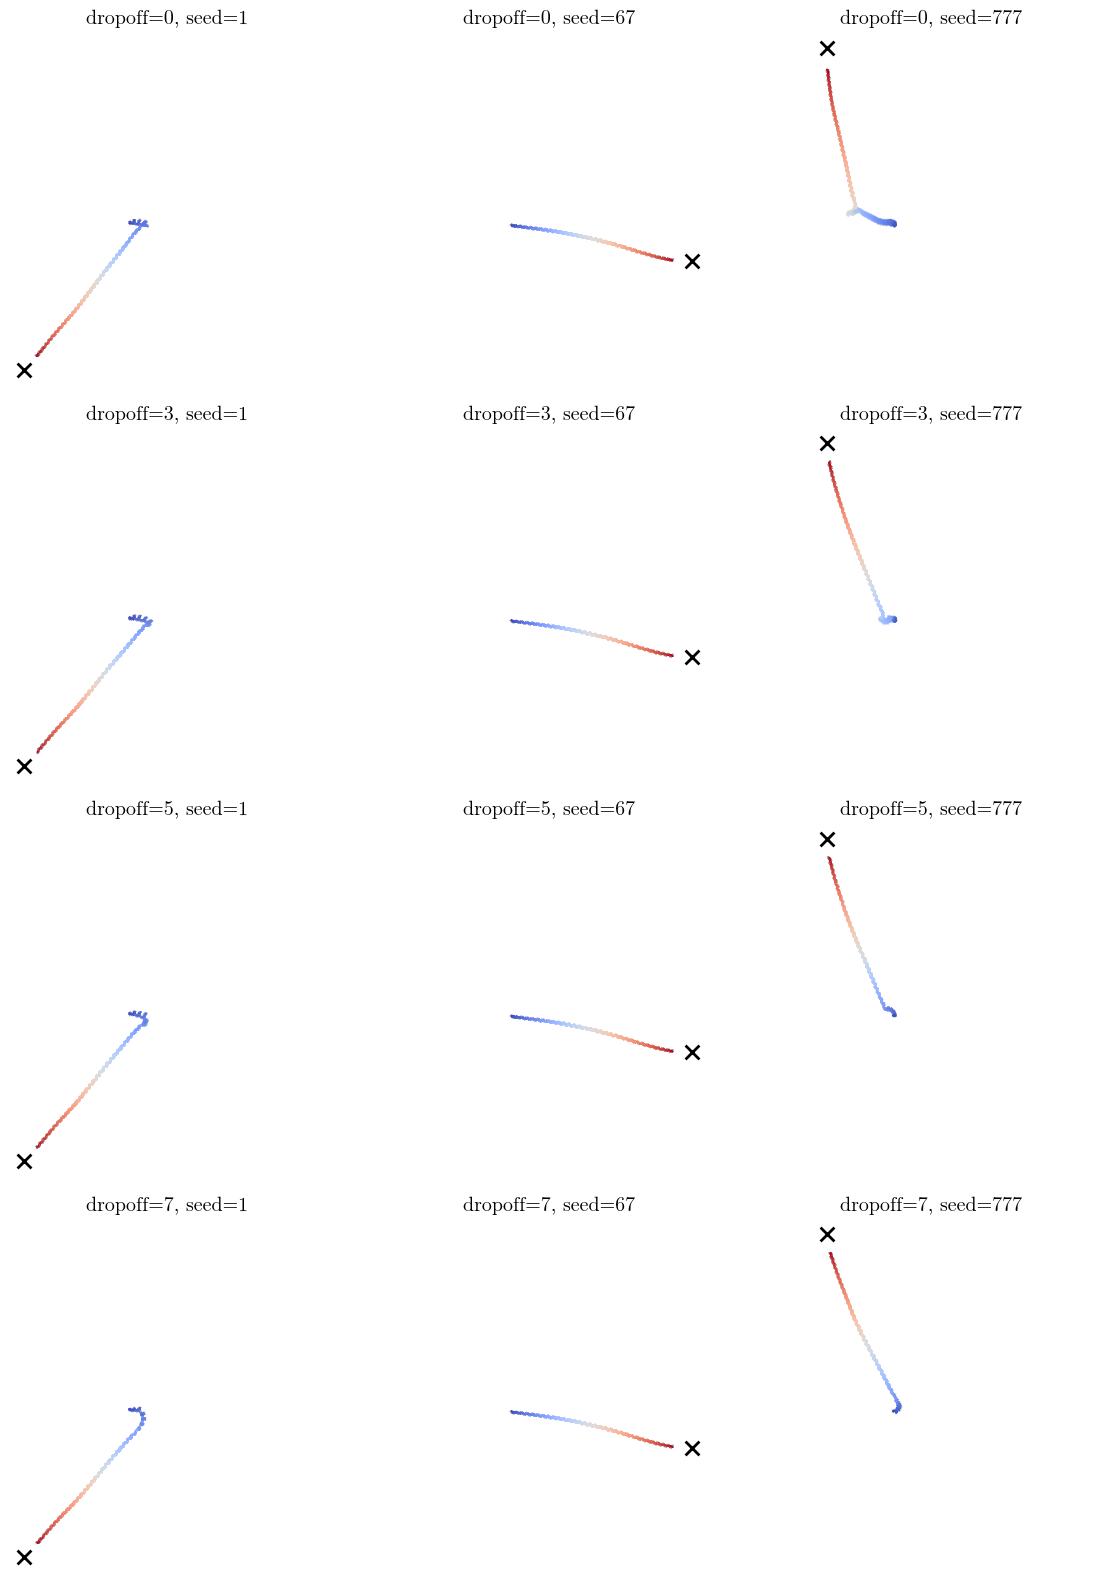

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

dropoffs = list(values.keys())
seeds = list(next(iter(values.values())).keys())

fig, axes = plt.subplots(
    len(dropoffs),
    len(seeds),
    figsize=(4 * len(seeds), 4 * len(dropoffs)),
    sharex=True,
    sharey=True,
)

for i, dropoff in enumerate(dropoffs):
    for j, seed in enumerate(seeds):
        ax = axes[i, j] if len(dropoffs) > 1 else axes[j]

        fly_pos = np.asarray(values[dropoff][seed]["fly_pos"][:-1])
        banana_pos = np.asarray(values[dropoff][seed]["banana_pos"])[0]

        xy = fly_pos[:, :2]

        points = xy.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        t = np.linspace(0, 1, len(segments))

        lc = LineCollection(
            segments,
            cmap="coolwarm",   # blue early, red late
            linewidth=1.8,
        )
        lc.set_array(t)

        ax.add_collection(lc)

        ax.scatter(
            banana_pos[0],
            banana_pos[1],
            marker="x",
            s=100,
            linewidths=2,
            color="black",
            label="Target",
        )

        ax.set_title(f"dropoff={dropoff}, seed={seed}")
        ax.set_aspect("equal", adjustable="box")
        ax.set_axis_off()

        if i == len(dropoffs) - 1:
            ax.set_xlabel("x")
        if j == 0:
            ax.set_ylabel("y")

        ax.autoscale()

plt.tight_layout()
plt.savefig("images/lv1_test.png")
plt.savefig("images/lv1_test.svg")
plt.savefig("images/lv1_test.pdf")
plt.show()

/var/folders/bf/r_50r8qd15b63xr26n0_ts640000gn/T/ipykernel_83179/2427609151.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


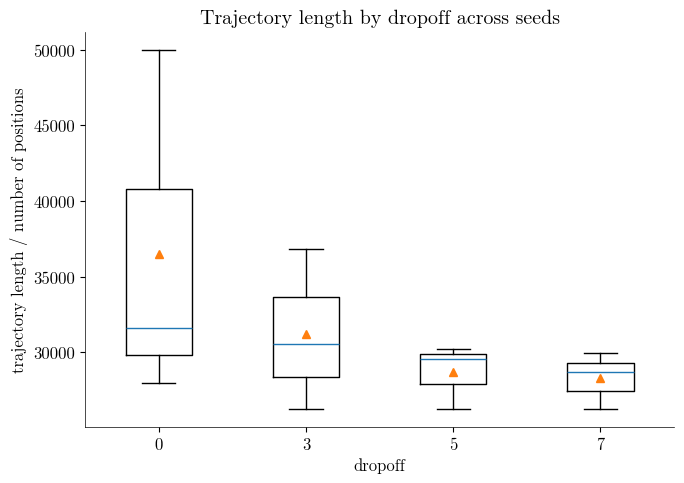

In [21]:
import matplotlib.pyplot as plt
import numpy as np

dropoffs = sorted(values.keys())

data = [
    [len(values[dropoff][seed]["fly_pos"]) for seed in values[dropoff].keys()]
    for dropoff in dropoffs
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    data,
    labels=dropoffs,
    showmeans=True,
)

plt.xlabel("dropoff")
plt.ylabel("trajectory length / number of positions")
plt.title("Trajectory length by dropoff across seeds")

plt.tight_layout()
plt.savefig("images/lv1_test_time.png")
plt.savefig("images/lv1_test_time.svg")
plt.savefig("images/lv1_test_time.pdf")
plt.show()